In [1]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


seed = 0

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/poisoned_data'
dataset_name = 'wikipedia'
ss_name = 'ts_tpr_remove_mss'

original_filename = rf'ml_{dataset_name}.csv'

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.rename(columns={'src': 'u', 'dst': 'i', 'time': 'ts'}, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/poisoned_data/wikipedia/ml_wikipedia.csv


,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2,8229,36.0,0.0,2
2,2,8229,77.0,0.0,3
3,3,8230,131.0,0.0,4
4,2,8229,150.0,0.0,5


In [2]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [21]:
attack_path = rf'{base_sparsified_path}/{dataset_name}/{ss_name}'
upto=0.7

# attack_path = os.path.join(base_sparsified_path, dataset_name)

# wikipedia_ts_tpr_remove_mss_sparsified_0.7.csv

filename = f"{dataset_name}_{ss_name}_sparsified_{upto}.csv"

attack_df = pd.read_csv(os.path.join(attack_path, filename))
attack_df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True)
attack_df.head()

,u,i,ts,label,idx
0,1.0,8228.0,0.000000,0.0,1.0
1,10.0,8241.0,1574.834857,NaN,NaN
2,15.0,8249.0,2259.563547,NaN,NaN
3,12.0,8242.0,2290.153625,NaN,NaN
4,12.0,8243.0,2290.153625,NaN,NaN


In [23]:
ns_df = attack_df[attack_df['ts'] < val_time]
# ns_df = attack_df[attack_df['ext_roll'] == 0]
# ns_df = attack_df[attack_df['is_negative'] == 1]
# ns_df.rename(columns={'src': 'u', 'dst': 'i', 'time': 'ts'}, inplace=True)
ns_df.sort_values('ts', inplace=True)
ns_df.reset_index(drop=True, inplace=True)
ns_df.head()

,u,i,ts,label,idx
0,1.0,8228.0,0.000000,0.0,1.0
1,10.0,8241.0,1574.834857,NaN,NaN
2,15.0,8249.0,2259.563547,NaN,NaN
3,12.0,8242.0,2290.153625,NaN,NaN
4,12.0,8243.0,2290.153625,NaN,NaN


In [24]:
len(orig_df), len(attack_df), len(ns_df)  # (110232, 156301, 109059)

(110232, 156301, 109059)

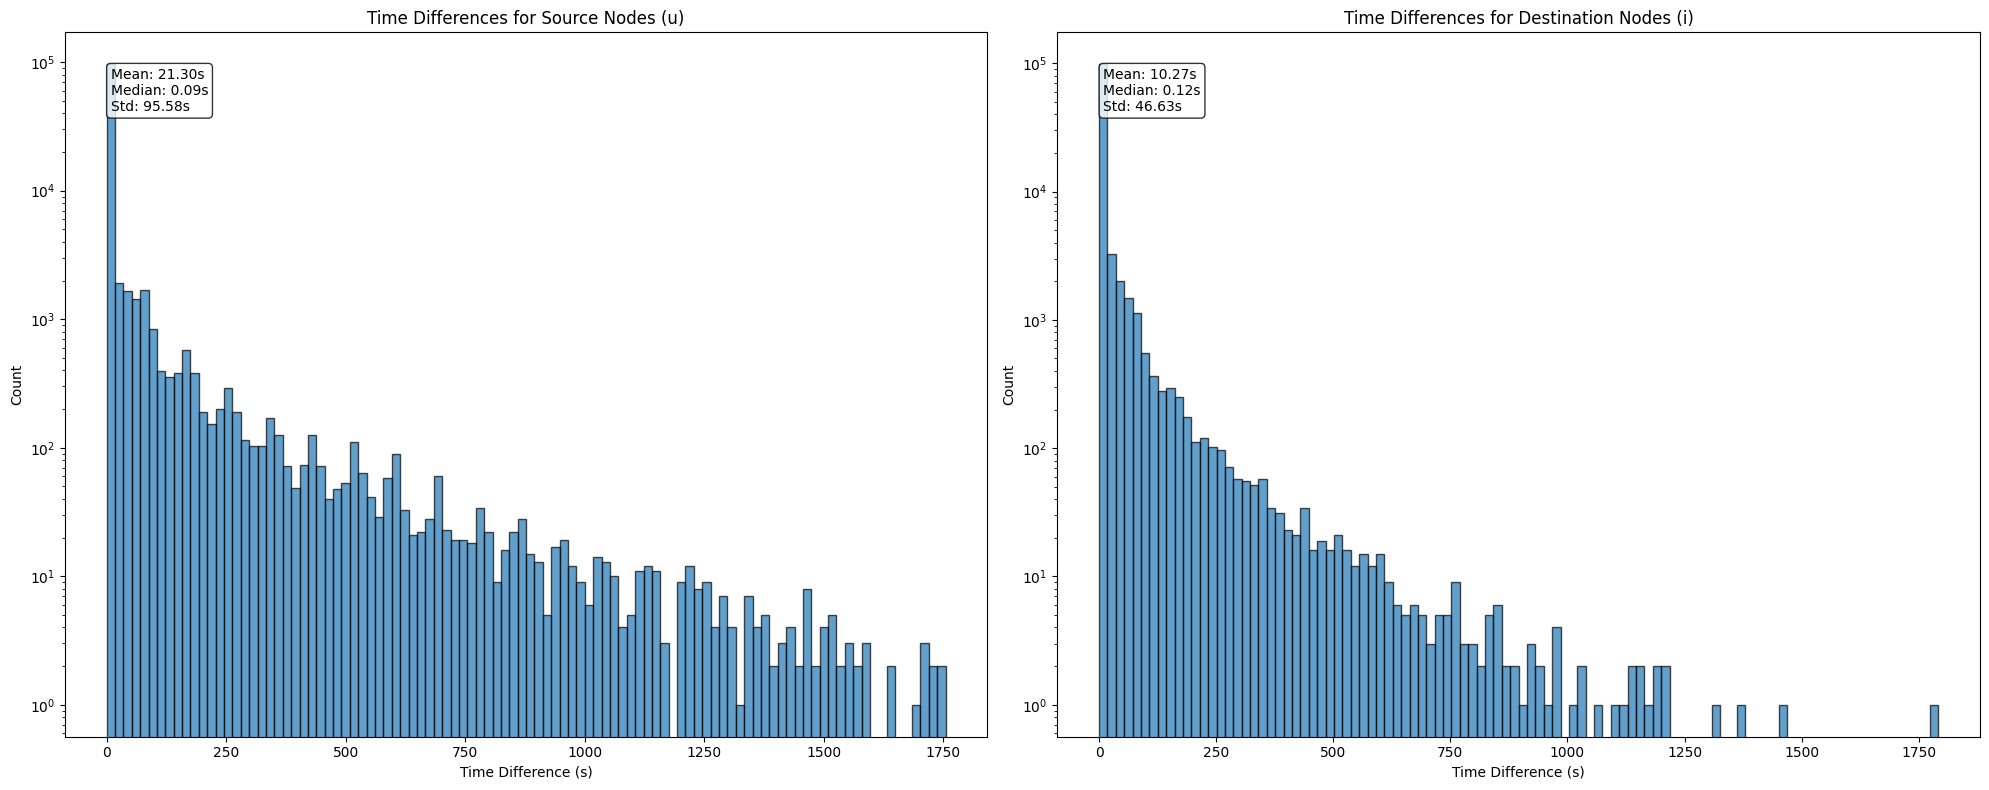

In [25]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# from collections import defaultdict


# def optimize_c3_checking(df):
#     """Precompute node appearance windows for faster C3 checking"""
#     df_sorted = df.sort_values('ts')
    
#     # Precompute node appearances
#     node_appearances = defaultdict(list)
#     for _, row in df_sorted.iterrows():
#         node_appearances[row['u']].append(row['ts'])
#         node_appearances[row['i']].append(row['ts'])
    
#     # Sort appearances for binary search
#     for node in node_appearances:
#         node_appearances[node] = np.array(sorted(node_appearances[node]))
    
#     return node_appearances

# def fast_check_c3_compliance(node_appearances, negative_samples, time_window):
#     """
#     Fast C3 compliance checking using binary search
    
#     Args:
#         node_appearances: Dict mapping nodes to sorted arrays of their timestamps
#         negative_samples: List/array of (u, i, ts) tuples to check
#         time_window: Time window size
#     """
#     compliant = []
    
#     for u, i, ts in negative_samples:
#         # Check source node
#         u_times = node_appearances.get(u, [])
#         if len(u_times) == 0:
#             compliant.append(False)
#             continue
            
#         # Binary search for window start in u's appearances
#         window_start = ts - time_window
#         u_idx = np.searchsorted(u_times, window_start)
#         if u_idx >= len(u_times) or u_times[u_idx] > ts:
#             compliant.append(False)
#             continue
            
#         # Check destination node
#         i_times = node_appearances.get(i, [])
#         if len(i_times) == 0:
#             compliant.append(False)
#             continue
            
#         # Binary search for window start in i's appearances
#         i_idx = np.searchsorted(i_times, window_start)
#         if i_idx >= len(i_times) or i_times[i_idx] > ts:
#             compliant.append(False)
#             continue
            
#         compliant.append(True)
        
#     return compliant

# def check_c3_compliance_optimized(df, negative_samples, time_window=1200):
#     """Wrapper for optimized C3 checking"""
#     # Precompute once
#     node_appearances = optimize_c3_checking(df)
    
#     # Check compliance
#     return fast_check_c3_compliance(node_appearances, negative_samples, time_window)

In [26]:
from collections import defaultdict

def optimize_c3_checking(df):
    """Precompute node appearance windows for faster C3 checking"""
    df_sorted = df.sort_values('ts')
    
    # Precompute node appearances
    node_appearances = defaultdict(list)
    for _, row in df_sorted.iterrows():
        node_appearances[row['u']].append(row['ts'])
        node_appearances[row['i']].append(row['ts'])
    
    return {node: sorted(times) for node, times in node_appearances.items()}

# def fast_check_c3_compliance(node_appearances, negative_samples, time_window):
#     """
#     Fast C3 compliance checking using binary search
    
#     Args:
#         node_appearances: Dict mapping nodes to sorted arrays of their timestamps
#         negative_samples: List/array of (u, i, ts) tuples to check
#         time_window: Time window size
#     """
#     compliant = []
    
#     for u, i, ts in negative_samples:
#         window_start = ts - time_window
        
#         # Check source node
#         u_times = node_appearances.get(u, [])
#         u_idx = np.searchsorted(u_times, window_start)
#         if not any(window_start <= t <= ts for t in u_times[u_idx:]):
#             compliant.append(False)
#             continue
            
#         # Check destination node
#         i_times = node_appearances.get(i, [])
#         i_idx = np.searchsorted(i_times, window_start)
#         if not any(window_start <= t <= ts for t in i_times[i_idx:]):
#             compliant.append(False)
#             continue
            
#         compliant.append(True)
        
#     return compliant

def fast_check_c3_compliance(node_appearances, negative_samples, time_window):
    compliant = []
    
    for u, i, ts in negative_samples:
        # Check source node
        u_times = node_appearances.get(u, [])
        if len(u_times) == 0:
            compliant.append(False)
            continue
        
        # Get last W timestamps for u
        u_idx = max(0, len(u_times) - time_window)
        if not any(t <= ts for t in u_times[u_idx:]):
            compliant.append(False)
            continue
        
        # Check destination node
        i_times = node_appearances.get(i, [])
        if len(i_times) == 0:
            compliant.append(False)
            continue
        
        # Get last W timestamps for i
        i_idx = max(0, len(i_times) - time_window)
        if not any(t <= ts for t in i_times[i_idx:]):
            compliant.append(False)
            continue
        
        compliant.append(True)
    
    return compliant


def check_c3_compliance_optimized(df, negative_samples, time_window=1200):
    """Wrapper for optimized C3 checking"""
    # Precompute once
    node_appearances = optimize_c3_checking(df)
    
    # Check compliance
    return fast_check_c3_compliance(node_appearances, negative_samples, time_window)


In [27]:
new_edges = ns_df[['u', 'i', 'ts']].values.tolist()

In [28]:
def check_c3_compliance(df, negative_samples, W=1200):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        # Find insertion point index
        insert_idx = df_sorted[df_sorted['ts'] <= ts].shape[0]
        # Get previous W edges
        window_start_idx = max(0, insert_idx - W)
        window_df = df_sorted.iloc[window_start_idx:insert_idx]
        # Get valid nodes from window
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

def check_c3_compliance_fast(df, negative_samples, W=1200):
    # Sort the dataframe once and reset the index for faster access
    df_sorted = df.sort_values('ts').reset_index(drop=True)
    timestamps = df_sorted['ts'].values
    u_column = df_sorted['u'].values
    i_column = df_sorted['i'].values

    compliant = []
    for u, i, ts in negative_samples:
        # Binary search to find the insertion point
        insert_idx = timestamps.searchsorted(ts, side='right')
        
        # Define the window start index
        window_start_idx = max(0, insert_idx - W)
        
        # Create the set of nodes in the window
        nodes_in_window = set(u_column[window_start_idx:insert_idx]) | set(i_column[window_start_idx:insert_idx])
        
        # Check compliance
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))

    return compliant


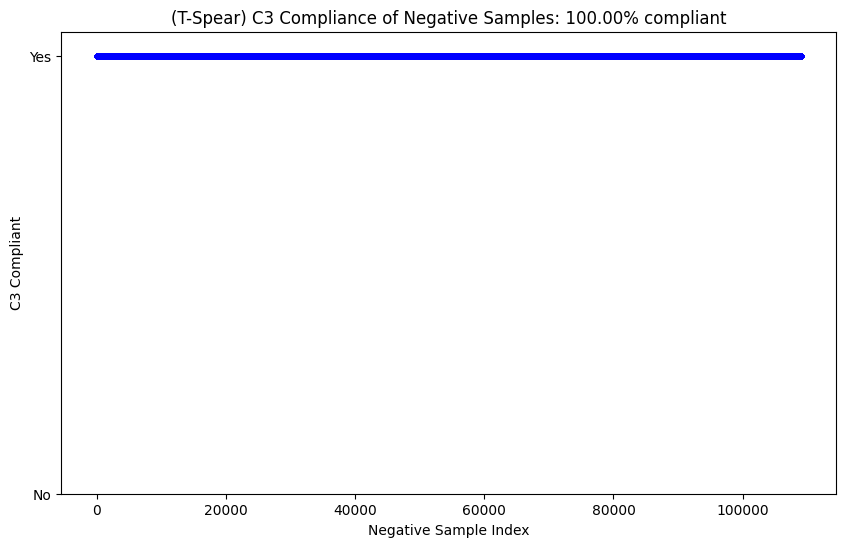

In [29]:
compliant = check_c3_compliance_optimized(orig_df, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'(T-Spear) C3 Compliance of Negative Samples: {sum(compliant)/len(compliant)*100:.2f}% compliant')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

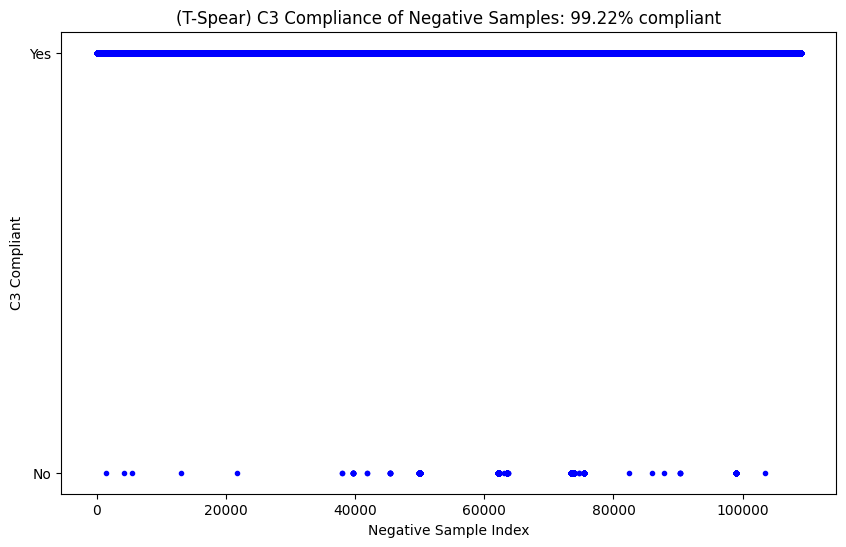

In [30]:
compliant = check_c3_compliance(orig_df, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'(T-Spear) C3 Compliance of Negative Samples: {sum(compliant)/len(compliant)*100:.2f}% compliant')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

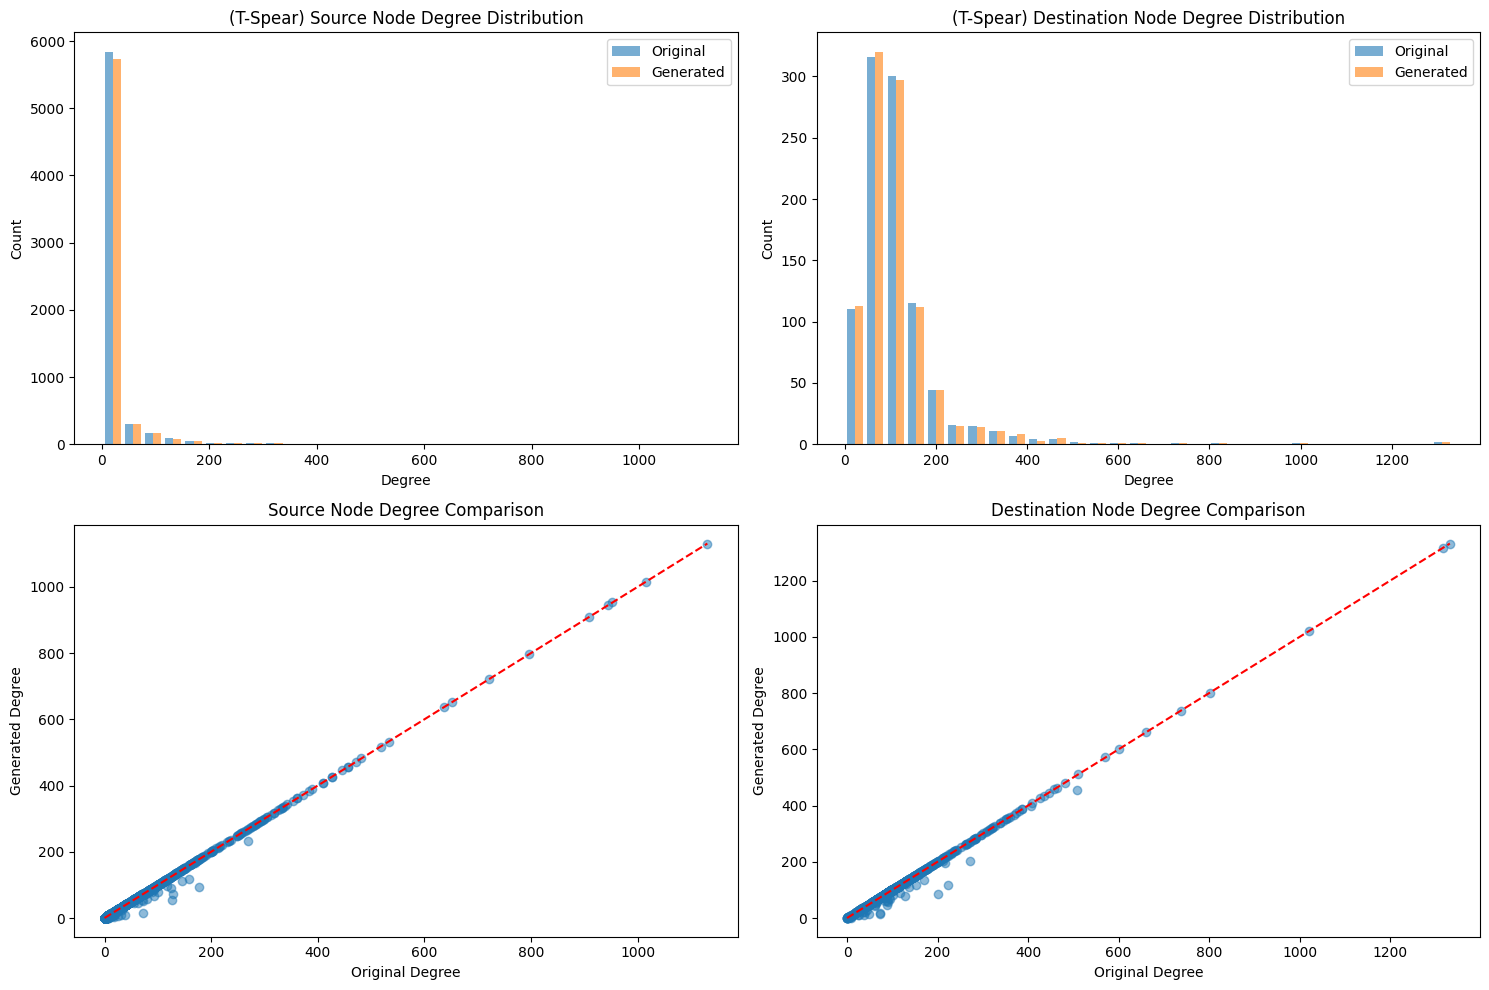

(T-Spear)Source degree correlation: nan
(T-Spear)Destination degree correlation: 0.997


In [31]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('(T-Spear) Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('(T-Spear) Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"(T-Spear)Source degree correlation: {src_corr:.3f}")
    print(f"(T-Spear)Destination degree correlation: {dst_corr:.3f}")
    

# use
plot_degree_comparison(orig_df, ns_df)

T-Spear somehow doesn't pass C3 and C4 doesnt make sense in our case as we are keeping the distribution same. Can we present this weakness of T-spear as our strength?